<img style="text-align: center" src='https://ensim.univ-lemans.fr/skins/ensim/resources/um_img/menu-gauche/lemans-universite-large.png' width="300" height="80">
<br>

<div style="margin-bottom:30px">
    <h1 style="text-align: center; color:#00B0F0; font-family:Sylfaen; font-size:34px;">Visualisation et exploration des donn?es</h1>
</div>

<div style="margin-bottom:30px">
    <h2 style="text-align: center; color:#00B0F0; font-family:Sylfaen; font-size:28px;">Projet</h2>
</div>

<div style="margin-bottom:20px">
    <p style="text-align: center; font-size:16px;">
        Objectif : EDA + Visualisation + Pr?paration des variables + Mod?lisation + Ciblage client
    </p>
</div>

---




## Organisation du notebook

1. **Préparation & chargement**
2. **Inspection rapide & qualité des données**
3. **Statistiques descriptives**
4. **Visualisation univariée**
5. **Analyse de la cible**
6. **Relations entre variables**
7. **Feature engineering**
8. **Préprocessing & modélisation**
9. **Prédictions sur les clients à contacter**
10. **Conclusion métier rédigée**


## Enoncé du problème

Une compagnie souhaite identifier les clients les plus pertinents à contacter pour une souscription.

Le fichier `train_info.csv` contient des clients avec une cible `reponse_client` indiquant s'ils ont répondu positivement ou non. Le fichier `clients_a_contacter.csv` contient les clients pour lesquels on veut produire une recommandation de contact.

L'objectif est de :
- comprendre les données,
- visualiser les profils clients,
- construire un modèle prédictif,
- générer une liste de ciblage exploitable.


# 0) Préparation

## 0.1 Imports
On utilisera : `pandas`, `numpy`, `matplotlib`, `seaborn`, `plotly` et `scikit-learn`.


In [29]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid")
%matplotlib inline


def show_plotly(fig):
    try:
        fig.show()
    except Exception as e:
        print("Affichage Plotly inline indisponible dans cet environnement.")
        print("Erreur:", e)
        print("Tentative d'ouverture dans le navigateur...")
        fig.show(renderer="browser")


## 0.2 Chemins de travail
Le notebook est prévu pour être exécuté depuis le dossier `Projet/`.


In [30]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "Data"

if not DATA_DIR.exists() and (BASE_DIR / "Projet" / "Data").exists():
    BASE_DIR = BASE_DIR / "Projet"
    DATA_DIR = BASE_DIR / "Data"

train_path = DATA_DIR / "train_info.csv"
prospects_path = DATA_DIR / "clients_a_contacter.csv"

print("BASE_DIR:", BASE_DIR)
print("train exists:", train_path.exists())
print("prospects exists:", prospects_path.exists())


BASE_DIR: c:\Users\Mayah\Desktop\4A\Visu des donnees\Projet
train exists: True
prospects exists: True


# 1) Chargement des données

## 1.1 Chargement des fichiers


In [31]:
train_df = pd.read_csv(train_path)
prospects_df = pd.read_csv(prospects_path)

print("Train shape:", train_df.shape)
print("Prospects shape:", prospects_df.shape)


Train shape: (381109, 12)
Prospects shape: (127037, 11)


+ Afficher les premières lignes des deux datasets.


In [32]:
display(train_df.head())
display(prospects_df.head())


,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete,reponse_client
0,1,male,44,1,28.0,0,> 2 ans,oui,40454.0,26.0,217,1
1,2,male,76,1,3.0,0,1-2 an,no,33536.0,26.0,183,0
2,3,male,47,1,28.0,0,> 2 ans,oui,38294.0,26.0,27,1
3,4,male,21,1,11.0,1,< 1 an,no,28619.0,152.0,203,0
4,5,femelle,29,1,41.0,1,< 1 an,no,27496.0,152.0,39,0


,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete
0,381110,male,25,1,11.0,1,< 1 an,no,35786.0,152.0,53
1,381111,male,40,1,28.0,0,1-2 an,oui,33762.0,7.0,111
2,381112,male,47,1,28.0,0,1-2 an,oui,40050.0,124.0,199
3,381113,male,24,1,27.0,1,< 1 an,oui,37356.0,152.0,187
4,381114,male,27,1,28.0,1,< 1 an,no,59097.0,152.0,297


# 2) Inspection rapide & qualité des données

## 2.1 Structure des données
Questions :
1. Combien de lignes et de colonnes ?
2. Quels sont les types des colonnes ?
3. Y a-t-il des valeurs manquantes ?
4. Quelles colonnes semblent être des identifiants ?


In [33]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id_client            381109 non-null  int64  
 1   genre                381109 non-null  object 
 2   age                  381109 non-null  int64  
 3   permis_conduire      381109 non-null  int64  
 4   code_regional        381109 non-null  float64
 5   ancien_assure        381109 non-null  int64  
 6   age_vehicule         381109 non-null  object 
 7   vehicule_endommage   381109 non-null  object 
 8   prime_annuelle       381109 non-null  float64
 9   canal_communication  381109 non-null  float64
 10  anciennete           381109 non-null  int64  
 11  reponse_client       381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [34]:
train_df.shape, prospects_df.shape


((381109, 12), (127037, 11))

## 2.2 Valeurs manquantes, doublons, unicité de l'identifiant


In [35]:
missing_train = train_df.isna().sum().sort_values(ascending=False)
missing_prospects = prospects_df.isna().sum().sort_values(ascending=False)

print("Valeurs manquantes - train")
display(missing_train.to_frame("missing"))

print("Valeurs manquantes - prospects")
display(missing_prospects.to_frame("missing"))

print("Doublons train:", train_df.duplicated().sum())
print("Doublons prospects:", prospects_df.duplicated().sum())
print("id_client unique dans train:", train_df["id_client"].is_unique)
print("id_client unique dans prospects:", prospects_df["id_client"].is_unique)


Valeurs manquantes - train


,missing
id_client,0
genre,0
age,0
permis_conduire,0
code_regional,0
ancien_assure,0
age_vehicule,0
vehicule_endommage,0
prime_annuelle,0
canal_communication,0


Valeurs manquantes - prospects


,missing
id_client,0
genre,0
age,0
permis_conduire,0
code_regional,0
ancien_assure,0
age_vehicule,0
vehicule_endommage,0
prime_annuelle,0
canal_communication,0


Doublons train: 0
Doublons prospects: 0
id_client unique dans train: True
id_client unique dans prospects: True


## 2.3 Typologie des variables
On distingue ici :
- l'identifiant : `id_client`
- la cible : `reponse_client`
- les variables quantitatives
- les variables catégorielles texte
- les variables binaires codées en nombres
- les variables codées numériquement mais à interpréter comme catégories


In [36]:
id_col = "id_client"
target_col = "reponse_client"

binary_cols = ["permis_conduire", "ancien_assure", "vehicule_endommage"]
text_cat_cols = ["genre", "age_vehicule"]
code_like_cols = ["code_regional", "canal_communication"]
numeric_cols = ["age", "prime_annuelle", "anciennete"]

damage_map = {"no": 0, "oui": 1, 0: 0, 1: 1}
train_df["vehicule_endommage"] = train_df["vehicule_endommage"].map(damage_map).astype("Int64")
prospects_df["vehicule_endommage"] = prospects_df["vehicule_endommage"].map(damage_map).astype("Int64")

summary_types = pd.DataFrame(
    {
        "role": [
            "identifiant",
            "cat?gorielle",
            "quantitative",
            "binaire",
            "cat?gorie cod?e",
            "binaire",
            "cat?gorielle ordinale",
            "binaire",
            "quantitative",
            "cat?gorie cod?e",
            "quantitative",
            "cible",
        ]
    },
    index=train_df.columns,
)
summary_types


,role
id_client,identifiant
genre,cat?gorielle
age,quantitative
permis_conduire,binaire
code_regional,cat?gorie cod?e
ancien_assure,binaire
age_vehicule,cat?gorielle ordinale
vehicule_endommage,binaire
prime_annuelle,quantitative
canal_communication,cat?gorie cod?e


# 3) Statistiques descriptives

## 3.1 Variables quantitatives


In [37]:
train_df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,381109.0,38.822584,15.511611,20.0,25.0,36.0,49.0,85.0
prime_annuelle,381109.0,30564.389581,17213.155057,2630.0,24405.0,31669.0,39400.0,540165.0
anciennete,381109.0,154.347397,83.671304,10.0,82.0,154.0,227.0,299.0


## 3.2 Variables binaires et catégorielles


In [38]:
for col in ["genre", "age_vehicule", "vehicule_endommage", "permis_conduire", "ancien_assure"]:
    print(f"{col}")
    display(train_df[col].value_counts(dropna=False).to_frame("effectif"))


genre


,effectif
genre,
male,206089
femelle,175020


age_vehicule


,effectif
age_vehicule,
1-2 an,200316
< 1 an,164786
> 2 ans,16007


vehicule_endommage


,effectif
vehicule_endommage,
1,192413
0,188696


permis_conduire


,effectif
permis_conduire,
1,380297
0,812


ancien_assure


,effectif
ancien_assure,
0,206481
1,174628


## 3.3 Détection simple des valeurs aberrantes
On utilise ici la régle de l'IQR sur les variables quantitatives.


In [39]:
outlier_rows = []

for col in numeric_cols:
    s = train_df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_outliers = ((s < low) | (s > high)).sum()
    outlier_rows.append(
        {
            "variable": col,
            "seuil_bas": low,
            "seuil_haut": high,
            "nb_outliers": int(n_outliers),
            "pct_outliers": n_outliers / len(s),
            "min": s.min(),
            "max": s.max(),
        }
    )

pd.DataFrame(outlier_rows)


,variable,seuil_bas,seuil_haut,nb_outliers,pct_outliers,min,max
0,age,-11.0,85.0,0,0.000000,20.0,85.0
1,prime_annuelle,1912.5,61892.5,10320,0.027079,2630.0,540165.0
2,anciennete,-135.5,444.5,0,0.000000,10.0,299.0


# 4) Visualisation univariée

## 4.1 Distributions des variables quantitatives


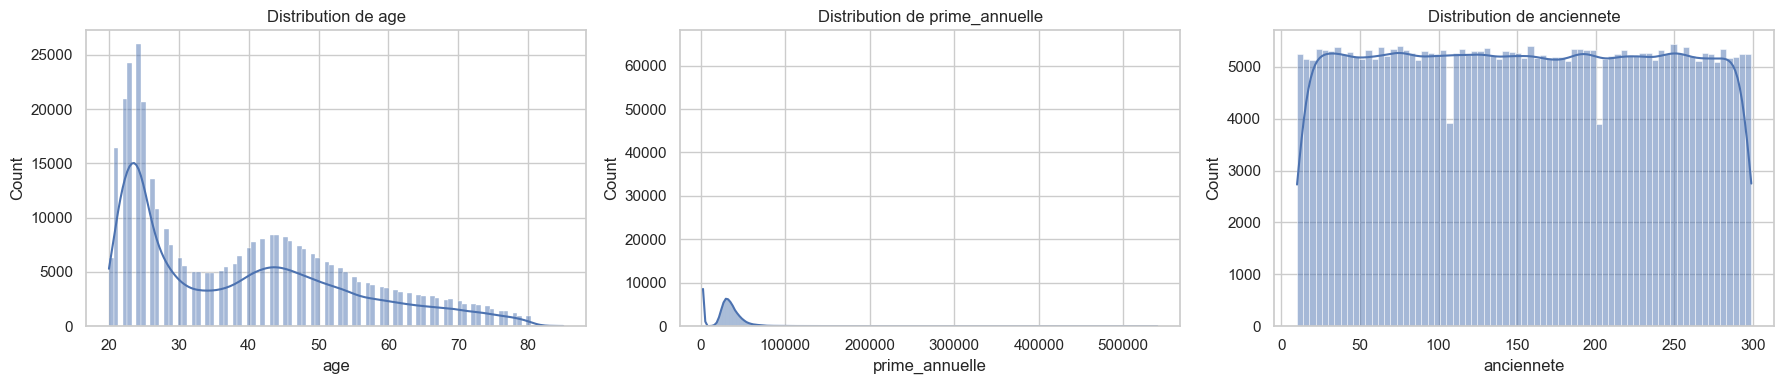

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(train_df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution de {col}")
plt.tight_layout()
plt.show()


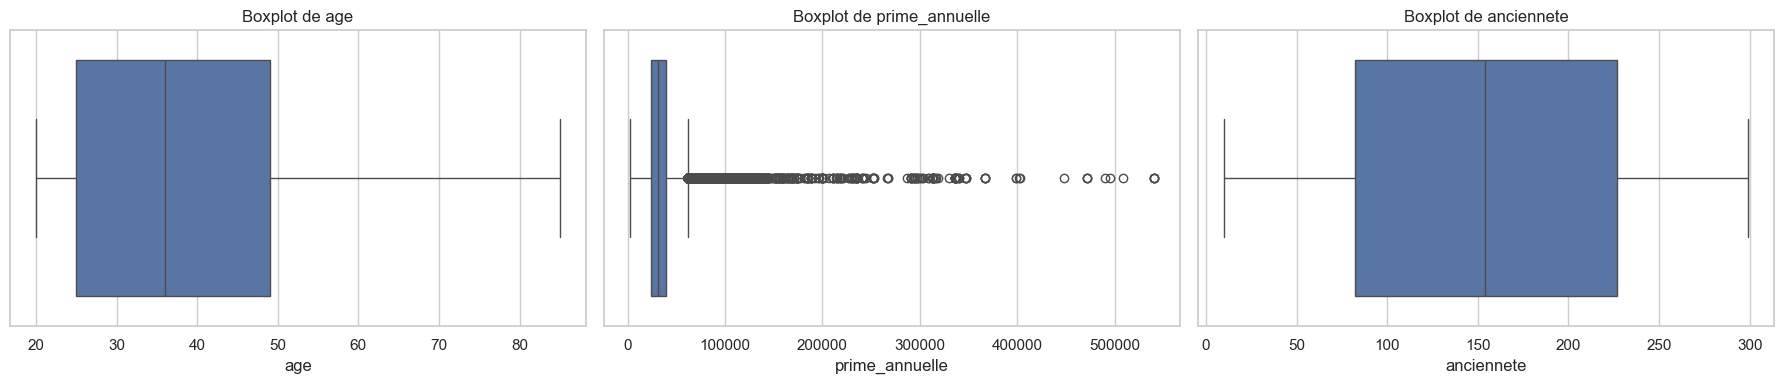

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=train_df[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()


## 4.2 Distributions des variables catégorielles


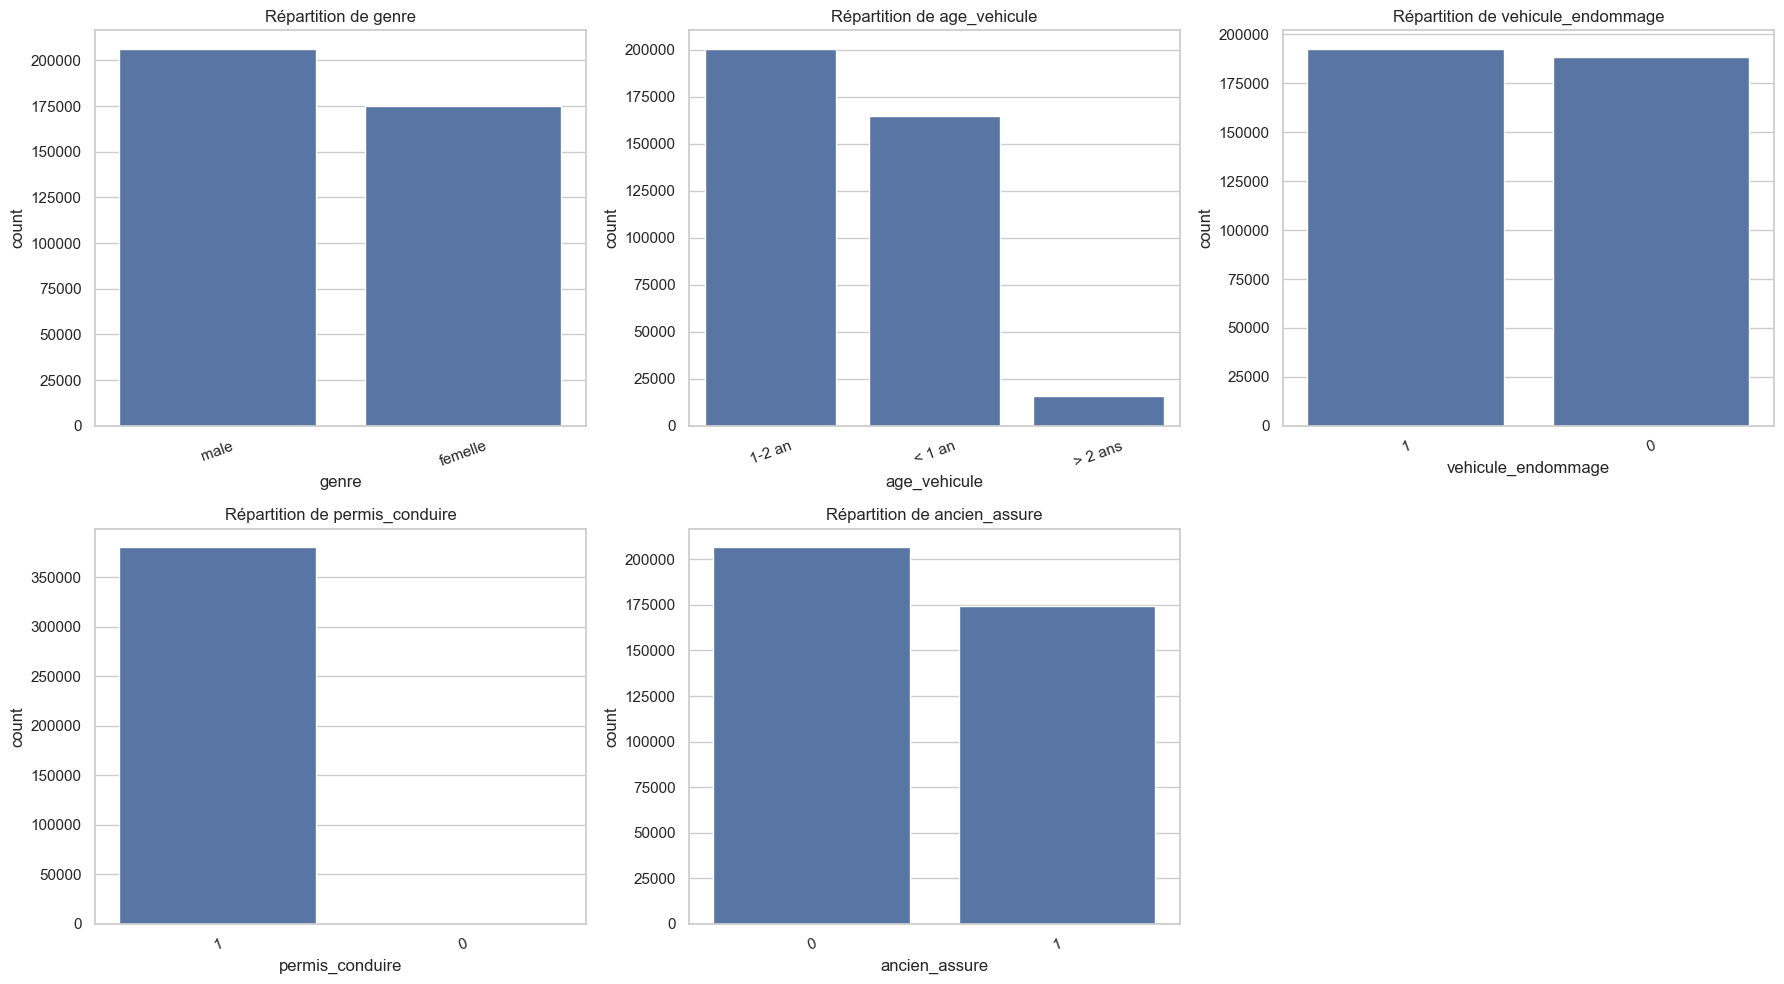

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
plot_cols = ["genre", "age_vehicule", "vehicule_endommage", "permis_conduire", "ancien_assure"]

for ax, col in zip(axes, plot_cols):
    order = train_df[col].value_counts().index
    sns.countplot(data=train_df, x=col, order=order, ax=ax)
    ax.set_title(f"Répartition de {col}")
    ax.tick_params(axis="x", rotation=20)

for ax in axes[len(plot_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# 5) Analyse de la cible

La variable cible est `reponse_client`. On vérifie son équilibre puis on regarde comment elle varie selon quelques caractéristiques client.


In [43]:
target_dist = train_df[target_col].value_counts(normalize=True).sort_index().rename("proportion")
display(target_dist.to_frame())

fig = px.bar(
    train_df[target_col].value_counts().sort_index().reset_index(),
    x="reponse_client",
    y="count",
    title="Distribution de la cible reponse_client",
)
show_plotly(fig)


,proportion
reponse_client,
0,0.877437
1,0.122563


In [44]:
for col in ["genre", "age_vehicule", "vehicule_endommage", "ancien_assure", "permis_conduire"]:
    tmp = train_df.groupby(col, dropna=False)[target_col].mean().sort_values(ascending=False)
    print(f"Taux de réponse par {col}")
    display(tmp.to_frame("taux_reponse"))


Taux de réponse par genre


,taux_reponse
genre,
male,0.138411
femelle,0.103902


Taux de réponse par age_vehicule


,taux_reponse
age_vehicule,
> 2 ans,0.293746
1-2 an,0.173755
< 1 an,0.043705


Taux de réponse par vehicule_endommage


,taux_reponse
vehicule_endommage,
1,0.237655
0,0.005204


Taux de réponse par ancien_assure


,taux_reponse
ancien_assure,
0,0.225454
1,0.000905


Taux de réponse par permis_conduire


,taux_reponse
permis_conduire,
1,0.122717
0,0.050493


# 6) Relations entre variables

## 6.1 Corrélation de Spearman
On inclut ici les variables numériques et binaires codées en nombres.


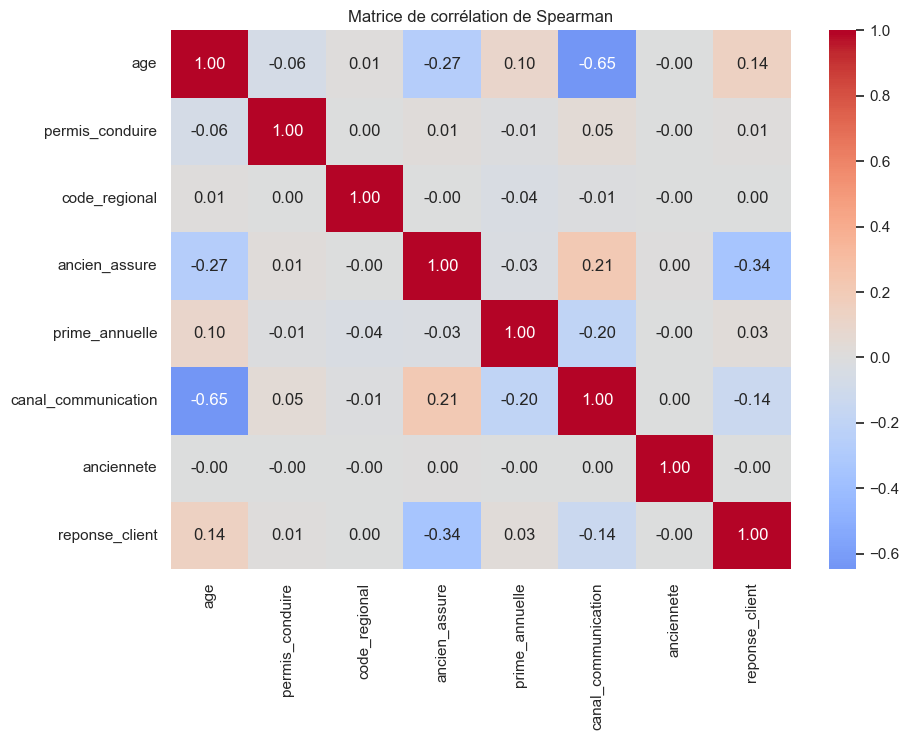

In [45]:
corr_cols = ["age", "permis_conduire", "code_regional", "ancien_assure", "prime_annuelle", "canal_communication", "anciennete", "reponse_client"]
spearman_corr = train_df[corr_cols].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice de corrélation de Spearman")
plt.show()


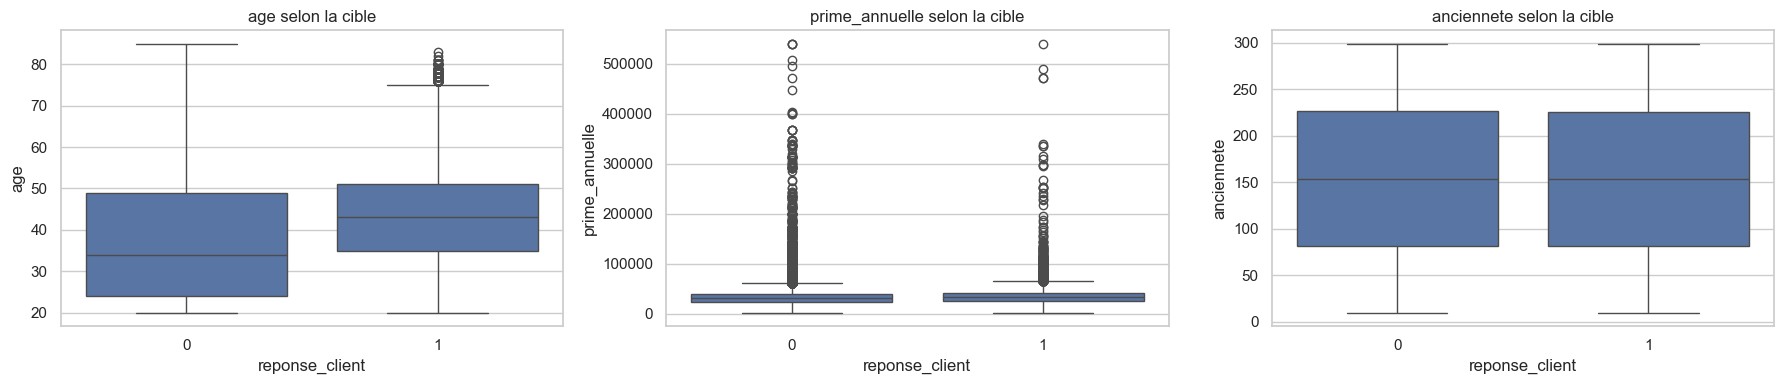

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=train_df, x=target_col, y=col, ax=ax)
    ax.set_title(f"{col} selon la cible")
plt.tight_layout()
plt.show()


# 7) Feature engineering

Cette ?tape pr?pare les variables pour la mod?lisation en respectant la logique demand?e dans l'?nonc?.

Les transformations r?alis?es sont les suivantes :
- conversion en type `category` des variables ? faible cardinalit?,
- cr?ation d'une variable `tranche_age` en 7 classes,
- cr?ation de variables d'interaction entre `tranche_age` et des variables li?es au v?hicule et ? l'assurance,
- encodage sp?cifique selon la nature des variables,
- pr?paration d'un pipeline r?utilisable ? l'identique sur `clients_a_contacter.csv`.


In [47]:
def add_features(df):
    df = df.copy()

    # 1) Conversion des variables ? faible cardinalit? en type category
    low_cardinality_cols = [
        col for col in df.columns
        if df[col].nunique(dropna=False) < 10 and col != "reponse_client"
    ]
    for col in low_cardinality_cols:
        df[col] = df[col].astype("category")

    # 2) Regroupement de l'?ge en 7 tranches
    df["tranche_age"] = pd.cut(
        df["age"],
        bins=[18, 25, 30, 35, 40, 50, 60, 100],
        labels=["18-25", "26-30", "31-35", "36-40", "41-50", "51-60", "61+"],
        include_lowest=True,
    ).astype("category")

    # 3) Variables d'interaction demand?es
    df["inter_age_vehicule"] = (
        df["tranche_age"].astype(str) + "__" + df["age_vehicule"].astype(str)
    ).astype("category")
    df["inter_age_dommage"] = (
        df["tranche_age"].astype(str) + "__" + df["vehicule_endommage"].astype(str)
    ).astype("category")
    df["inter_age_assure"] = (
        df["tranche_age"].astype(str) + "__" + df["ancien_assure"].astype(str)
    ).astype("category")

    return df

train_fe = add_features(train_df)
prospects_fe = add_features(prospects_df)

train_fe.head()


,id_client,genre,age,permis_conduire,code_regional,ancien_assure,age_vehicule,vehicule_endommage,prime_annuelle,canal_communication,anciennete,reponse_client,tranche_age,age_vehicule_ord,interaction_dommage_assure
0,1,male,44,1,28.0,0,> 2 ans,1,40454.0,26.0,217,1,36-45,2,1_0
1,2,male,76,1,3.0,0,1-2 an,0,33536.0,26.0,183,0,66+,1,0_0
2,3,male,47,1,28.0,0,> 2 ans,1,38294.0,26.0,27,1,46-55,2,1_0
3,4,male,21,1,11.0,1,< 1 an,0,28619.0,152.0,203,0,18-25,0,0_1
4,5,femelle,29,1,41.0,1,< 1 an,0,27496.0,152.0,39,0,26-30,0,0_1


In [48]:
class BinaryRateEncoder(BaseEstimator, TransformerMixin):
    """Encode une modalit? en 1 si son taux de r?ponse est sup?rieur ou ?gal au taux moyen global, sinon 0."""

    def __init__(self, cols=None):
        self.cols = cols or []
        self.global_mean_ = None
        self.maps_ = {}

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(y)
        self.global_mean_ = float(y.mean())

        for col in self.cols:
            tmp = pd.DataFrame({col: X[col], "target": y})
            rates = tmp.groupby(col)["target"].mean()
            self.maps_[col] = (rates >= self.global_mean_).astype(int).to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        out = pd.DataFrame(index=X.index)
        for col in self.cols:
            out[col + "_bin"] = X[col].map(self.maps_[col]).fillna(0).astype(int)
        return out


## Ce qu'on entra?ne exactement

Dans `train_info.csv`, chaque ligne correspond ? un client observ? avec une cible connue `reponse_client`.

Le mod?le apprend donc ? pr?dire la probabilit? qu'un client r?ponde positivement ? partir de ses caract?ristiques.

- `X` : les variables explicatives transform?es,
- `y` : la cible `reponse_client`,
- `train_test_split` : s?paration entra?nement / test,
- `fit` sur le train uniquement,
- `transform` identique sur le test puis sur `clients_a_contacter.csv`.


# 8) Préprocessing & modélisation

## 8.1 Séparation train / test

On sépare les données en deux parties :
- un sous-ensemble d'entraînement pour apprendre le modéle,
- un sous-ensemble de test pour évaluer ses performances sur des données non vues.

Cette étape est indispensable pour vérifier que le modéle généralise correctement.


In [49]:
feature_cols = [
    "genre",
    "age",
    "permis_conduire",
    "code_regional",
    "ancien_assure",
    "age_vehicule",
    "vehicule_endommage",
    "prime_annuelle",
    "canal_communication",
    "anciennete",
    "tranche_age",
    "inter_age_vehicule",
    "inter_age_dommage",
    "inter_age_assure",
]

target = train_fe[target_col]
X = train_fe[feature_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    target,
    test_size=0.25,
    random_state=42,
    stratify=target,
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(285831, 13) (95278, 13) (285831,) (95278,)


In [50]:
one_hot_cols = [
    "genre",
    "vehicule_endommage",
    "tranche_age",
    "inter_age_vehicule",
    "inter_age_dommage",
    "inter_age_assure",
]
ordinal_cols = ["age_vehicule"]
minmax_cols = ["age", "permis_conduire"]
robust_cols = ["prime_annuelle"]
standard_cols = ["ancien_assure", "anciennete"]
high_card_cols = ["code_regional", "canal_communication"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "onehot",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ("scaler", StandardScaler(with_mean=False)),
            ]),
            one_hot_cols,
        ),
        (
            "ordinal",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OrdinalEncoder(
                        categories=[["< 1 an", "1-2 an", "> 2 ans"]],
                        handle_unknown="use_encoded_value",
                        unknown_value=-1,
                    ),
                ),
                ("scaler", StandardScaler()),
            ]),
            ordinal_cols,
        ),
        (
            "minmax",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", MinMaxScaler()),
            ]),
            minmax_cols,
        ),
        (
            "robust",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", RobustScaler()),
            ]),
            robust_cols,
        ),
        (
            "standard",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            standard_cols,
        ),
        (
            "high_card_binary",
            Pipeline([
                ("encoder", BinaryRateEncoder(cols=high_card_cols)),
                ("scaler", StandardScaler()),
            ]),
            high_card_cols,
        ),
    ],
    remainder="drop",
)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=1,
    ),
}


In [51]:
results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    row = {
        "modele": name,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    results.append(row)
    trained_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df


,modele,precision,recall,f1,roc_auc
0,LogisticRegression,0.282227,0.917880,0.431713,0.851281
1,RandomForest,0.360852,0.119027,0.179008,0.833460


In [52]:
best_model_name = results_df.iloc[0]["modele"]
best_pipe = trained_pipelines[best_model_name]

print("Meilleur modèle:", best_model_name)

y_pred_best = best_pipe.predict(X_test)
y_proba_best = best_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_best))


Meilleur modèle: LogisticRegression
              precision    recall  f1-score   support

           0       0.98      0.67      0.80     83600
           1       0.28      0.92      0.43     11678

    accuracy                           0.70     95278
   macro avg       0.63      0.80      0.62     95278
weighted avg       0.90      0.70      0.75     95278

Confusion matrix:
[[56339 27261]
 [  959 10719]]


# 9) Prédictions sur les clients à contacter

On applique exactement les mêmes transformations au fichier `clients_a_contacter.csv`.


In [53]:
X_prospects = prospects_fe[feature_cols].copy()
prospects_predictions = prospects_fe[["id_client"]].copy()
prospects_predictions["proba_reponse"] = best_pipe.predict_proba(X_prospects)[:, 1]
prospects_predictions["classe_predite"] = best_pipe.predict(X_prospects)

# Exemple simple de segmentation m?tier
prospects_predictions["segment_contact"] = pd.cut(
    prospects_predictions["proba_reponse"],
    bins=[0, 0.3, 0.7, 1.0],
    labels=["faible_priorite", "priorite_intermediaire", "haute_priorite"],
    include_lowest=True,
)

prospects_predictions = prospects_predictions.sort_values("proba_reponse", ascending=False)
prospects_predictions.head(20)


,id_client,proba_reponse,classe_predite,segment_contact
114728,495838,0.994945,1,haute_priorite
40907,422017,0.993462,1,haute_priorite
93997,475107,0.990915,1,haute_priorite
74751,455861,0.917961,1,haute_priorite
84033,465143,0.916033,1,haute_priorite
81127,462237,0.914758,1,haute_priorite
6819,387929,0.912146,1,haute_priorite
62939,444049,0.909371,1,haute_priorite
88086,469196,0.906608,1,haute_priorite
94045,475155,0.906600,1,haute_priorite


In [54]:
output_path = BASE_DIR / "predictions_clients_a_contacter.csv"
prospects_predictions.to_csv(output_path, index=False)
print("Fichier export?:", output_path)


Fichier export?: c:\Users\Mayah\Desktop\4A\Visu des donnees\Projet\predictions_clients_a_contacter.csv


In [55]:
fig = px.histogram(
    prospects_predictions,
    x="proba_reponse",
    nbins=40,
    color="segment_contact",
    title="Distribution des probabilit?s pr?dites",
)
show_plotly(fig)


# 10) Conclusion métier

## Conclusion 


